# Quickstart

This notebook renders an SVG onto a matplotlib axes, shows how the y-axis flip
works, and inspects the parsed scene. Every example uses inline SVG markup so the
notebook is self-contained, but you can pass a file path to
[`add_svg`][svg2mpl.add_svg] just as easily.

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt

import svg2mpl

print("svg2mpl", svg2mpl.__version__)

svg2mpl 0.1.0


## Render a drawing

We start from a small SVG with a rectangle, a circle, a polygon, and a line --
wrapped in a `<g>` group with a `transform`. `svg2mpl` bakes the group transform,
the `viewBox`, and the per-element styling into matplotlib artists.

In [3]:
BASIC_SVG = """
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100">
  <g transform="translate(10, 10)">
    <rect id="r" x="0" y="0" width="40" height="20" fill="#3366cc"/>
    <circle id="c" cx="60" cy="30" r="15" fill="red" stroke="black" stroke-width="2"/>
  </g>
  <polygon id="p" points="10,90 50,60 90,90" fill="green" opacity="0.5"/>
  <line id="l" x1="0" y1="0" x2="100" y2="100" stroke="purple" stroke-width="3"/>
</svg>
"""

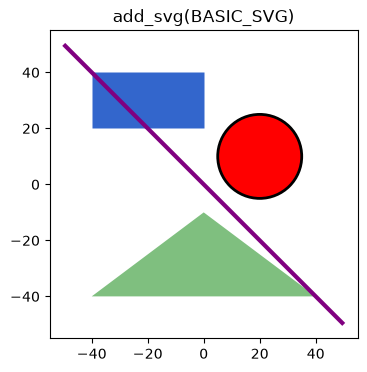

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
svg2mpl.add_svg(BASIC_SVG, ax=ax)
ax.set_aspect("equal")
ax.set_title("add_svg(BASIC_SVG)")
plt.show()

## The y-axis flip

SVG's y-axis points **down**; matplotlib's points **up**. By default `add_svg`
flips the y-axis so the drawing matches what a browser shows. Pass
`flip_y=False` to keep the raw SVG coordinates (note the drawing appears
mirrored vertically).

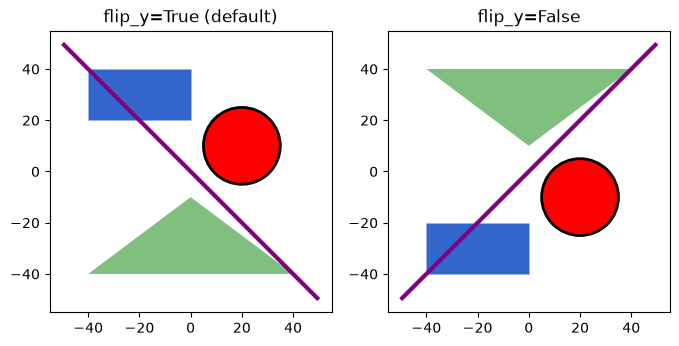

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

svg2mpl.add_svg(BASIC_SVG, ax=axes[0])
axes[0].set_title("flip_y=True (default)")

svg2mpl.add_svg(BASIC_SVG, ax=axes[1], flip_y=False)
axes[1].set_title("flip_y=False")

for ax in axes:
    ax.set_aspect("equal")
plt.show()

## Inspecting the scene

[`load`][svg2mpl.load] parses an SVG into a [`Scene`][svg2mpl.Scene] without
drawing anything, so you can read off the document size and the matplotlib kwargs
resolved for each shape.

In [6]:
scene = svg2mpl.load_string(BASIC_SVG)
print("document size:", scene.width, "x", scene.height)
for shape in scene.shapes:
    print(f"  {shape.id!r:6} -> {shape.kwargs}")

document size: 100.0 x 100.0
  'r'    -> {'facecolor': '#3366cc', 'edgecolor': 'none', 'linewidth': 1.0, 'alpha': 1.0}
  'c'    -> {'facecolor': 'red', 'edgecolor': 'black', 'linewidth': 2.0, 'alpha': 1.0}
  'p'    -> {'facecolor': 'green', 'edgecolor': 'none', 'linewidth': 1.0, 'alpha': 0.5}
  'l'    -> {'facecolor': 'black', 'edgecolor': 'purple', 'linewidth': 3.0, 'alpha': 1.0}
